# Make correlated Gaussian realisations of TOD given some underlying spectrum.

In [2]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np, sys, os, warnings
from FlatSkyLab import flatsky
from FlatSkyLab import tod_tools

from pylab import *
cmap = cm.RdYlBu_r


In [7]:
rcParams['figure.dpi'] = 150
rcParams["figure.facecolor"] = 'white'

In [8]:
#get params for sim generation
fmin = 200 #remove some largest-scale modes
fmax = 10000
freq = np.arange(fmax)

#sim specs
nsims = 25

#define some detectors
total_detectors = 5 ##5
detector_array = np.arange( total_detectors )

#TOD specs
sample_freq = 200. #Hz
tod_len = 10000
tod_shape = [tod_len]

#rough noise specs - similar to SPT (https://arxiv.org/pdf/2106.11202).
tod_noise_level = 1e3 #in, for example, uK/\sqrt(seconds), units. (Fig. 11 of https://arxiv.org/pdf/2106.11202).
fknee = 0.2 ##0.05 #Hz (Fig. 11 of https://arxiv.org/pdf/2106.11202).
alphaknee = 3.
rho_one_over_f = 0.7 #some level of 1/f correlation between detectors.

# Noise model

/usr/local/lib/python3.9/site-packages/FlatSkyLab/tod_tools.py:43: RuntimeWarning: divide by zero encountered in true_divide
  noise_powspec_one_over_f = noise_level**2. * (fknee/freq)**alphaknee


dict_keys([(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)])


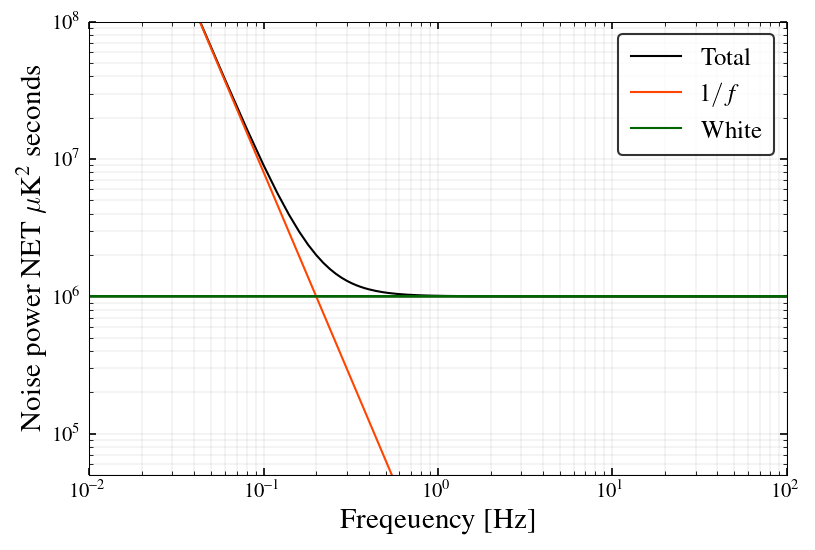

In [9]:
#example noise model for auto- and cross-power between detectors
freq, noise_powspec, noise_powspec_one_over_f, noise_powspec_white = tod_tools.detector_noise_model(tod_noise_level, fknee, alphaknee, tod_len, sample_freq)
cross_noise_powspec = tod_tools.get_correlated_powspec(rho_one_over_f, noise_powspec_one_over_f, noise_powspec_one_over_f)
noise_powspec_dic = {}
for i in range(total_detectors):
    for j in range(total_detectors):
        if i == j:
            noise_powspec_dic[i, j] = noise_powspec
        else:
            noise_powspec_dic[i, j] = cross_noise_powspec
print(noise_powspec_dic.keys())
if (1): #plot
    clf()
    fsval = 14
    ax = subplot(111, yscale = 'log', xscale = 'log')
    plot( freq, noise_powspec, label = r'Total', color = 'black' )
    plot( freq, noise_powspec_one_over_f, label = r'$1/f$', color = 'orangered' )
    plot( freq, noise_powspec_white, label = r'White', color = 'darkgreen' )
    xlabel(r'Freqeuency [Hz]', fontsize = fsval)
    ylabel(r'Noise power NET $\mu$K$^{2}$ seconds', fontsize = fsval)
    grid(True, lw = 0.2, alpha = 0.2, which = 'both')
    xlim(1e-2, 1e2); ylim(5e4, 1e8); 
    legend(loc = 1, fontsize = fsval - 2)
    show()

# Perform simulations now

In [10]:
tod_sims_dic = {}
pspec_dic_sims = {}
for sim_no in range( nsims ):
    print('Sim = %s of %s' %(sim_no+1, nsims))
    tod_sim_arr = flatsky.make_gaussian_realisations(freq, noise_powspec_dic, tod_shape, 1./sample_freq)
    ##print( tod_sim_arr ); ##sys.exit()
    
    #get the sim spectra now.
    curr_sim_pspec_dic = {}
    for (cntr1, tod1) in enumerate( tod_sim_arr ):
        for (cntr2, tod2) in enumerate( tod_sim_arr ):
            if cntr2<cntr1: continue
                
            if (0):
                ax = subplot(111)
                plot( tod1 )
                show(); sys.exit()
            
            freq = np.fft.fftfreq(tod_len, 1/sample_freq) #TOD frequencies.
            curr_spec = ( np.fft.fft(tod1) * (1/sample_freq) * np.conj( np.fft.fft(tod2) * (1/sample_freq) ) / tod_len  ).real

            if (0):
                inds = np.where(freq>0)
                curr_noise_powspec = noise_powspec_dic[(cntr1, cntr2)]
                clf()
                fsval = 14
                ax = subplot(111, yscale = 'log', xscale = 'log')
                plot( freq[inds], curr_noise_powspec[inds], label = r'Input', color = 'black' )
                plot( freq[inds], curr_spec[inds], color = 'orangered', label = r'Sims' )
                xlabel(r'Freqeuency [Hz]', fontsize = fsval)
                ylabel(r'Noise power NET $\mu$K$^{2}$ seconds', fontsize = fsval)
                grid(True, lw = 0.2, alpha = 0.2, which = 'both')
                #ylim(5e4, 1e8); 
                xlim(1e-2, 1e2)
                legend(loc = 1, fontsize = fsval - 2)
                show(); ##sys.exit()
                
            curr_sim_pspec_dic[(cntr1, cntr2)] = [freq, curr_spec]
    pspec_dic_sims[sim_no] = curr_sim_pspec_dic
    
print('Done')

Sim = 1 of 25
Sim = 2 of 25
Sim = 3 of 25
Sim = 4 of 25
Sim = 5 of 25
Sim = 6 of 25
Sim = 7 of 25
Sim = 8 of 25
Sim = 9 of 25
Sim = 10 of 25
Sim = 11 of 25


/usr/local/lib/python3.9/site-packages/FlatSkyLab/flatsky.py:420: RuntimeWarning: invalid value encountered in sqrt
  tij_dic[(i,j)] = tij_dic[(j,i)]= np.sqrt( t1-t2 )
/usr/local/lib/python3.9/site-packages/FlatSkyLab/flatsky.py:428: RuntimeWarning: divide by zero encountered in true_divide
  tij_dic[(i,j)] = (t1-t2)/t3
/usr/local/lib/python3.9/site-packages/FlatSkyLab/flatsky.py:447: RuntimeWarning: invalid value encountered in multiply
  curr_sim_fft = curr_sim_fft * norm


Sim = 12 of 25
Sim = 13 of 25
Sim = 14 of 25
Sim = 15 of 25
Sim = 16 of 25
Sim = 17 of 25
Sim = 18 of 25
Sim = 19 of 25
Sim = 20 of 25
Sim = 21 of 25
Sim = 22 of 25
Sim = 23 of 25
Sim = 24 of 25
Sim = 25 of 25
Done


[0, 0] 0 0
[1, 1] 1 1
[2, 2] 2 2
[3, 3] 3 3
[4, 4] 4 4
[0, 1] 0 1
[0, 2] 0 2
[0, 3] 0 3
[0, 4] 0 4
[1, 2] 1 2
[1, 3] 1 3
[1, 4] 1 4
[2, 3] 2 3
[2, 4] 2 4
[3, 4] 3 4


<Figure size 900x600 with 0 Axes>

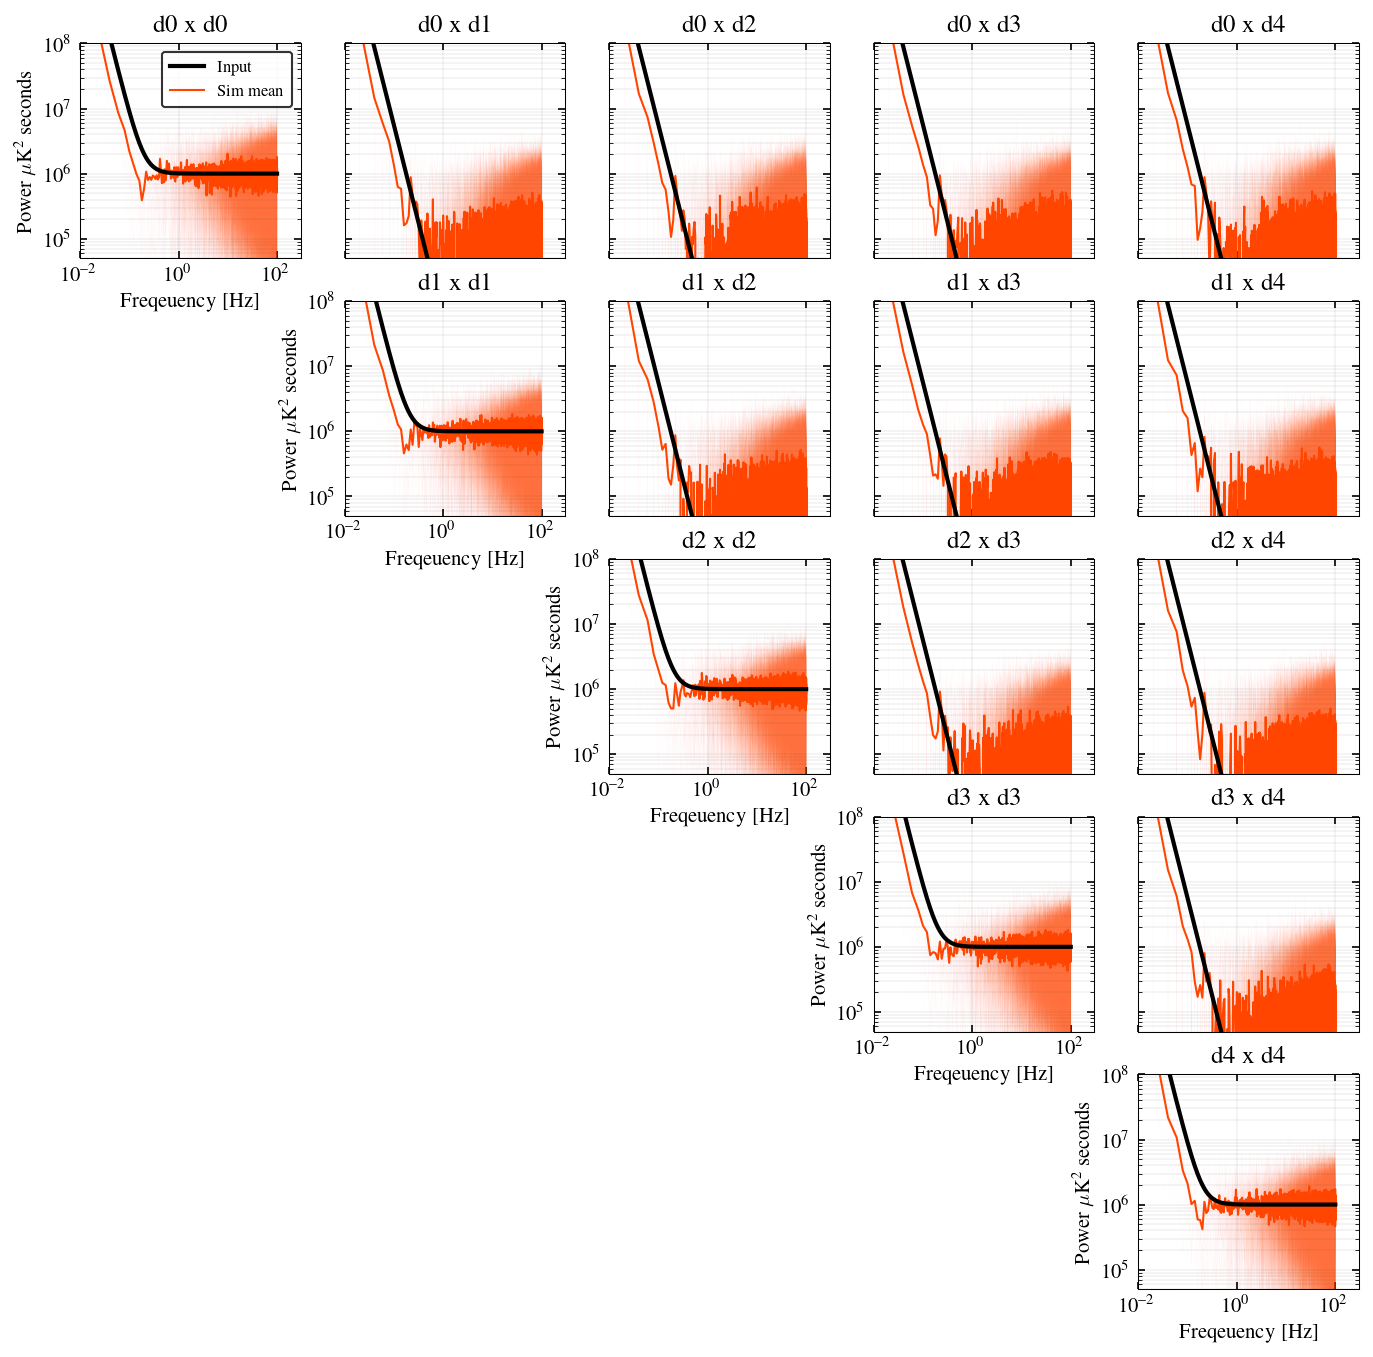

In [11]:
#make plots of the input vs output power spectra.
detector_arr = np.arange(total_detectors)
detector_arr_to_plot = np.asarray( detector_arr )
if total_detectors > 5:
    detector_arr_to_plot = detector_arr_to_plot[:8]
detector_combs_for_plotting_autos = [[detector, detector] for detector in detector_arr_to_plot]
detector_combs_for_plotting_crosses = [[detector1, detector2] for detector1 in detector_arr_to_plot for detector2 in detector_arr_to_plot if (detector1!=detector2 and detector1<detector2)]
detector_combs_for_plotting = detector_combs_for_plotting_autos + detector_combs_for_plotting_crosses

close('all')
clf()
fsval = 12
tr, tc = len(detector_arr_to_plot), len(detector_arr_to_plot)
subplots_adjust( hspace = 0.2, wspace = 0.1)
sbpl = 1
figure(figsize = (tr+6, tc+6))
#figure(figsize = (tr+2, tc+2))

for d1d2 in detector_combs_for_plotting:
    d1, d2 = d1d2

    rowval, colval = np.where(detector_arr_to_plot == d1)[0][0], np.where(detector_arr_to_plot == d2)[0][0]
    print(d1d2, rowval, colval)
    ax = subplot2grid((tr, tc), (rowval, colval), yscale = 'log', xscale = 'log')

    freq = np.fft.fftfreq(tod_len, 1/sample_freq) #TOD frequencies.
    inds = np.where(freq>0)
    curr_theory = noise_powspec_dic[(d1, d2)]
    #theory
    plot( freq[inds], curr_theory[inds], color = 'black', label = r'Input', lw = 2., zorder = 100)

    #sims
    colorval = 'orangered'
    curr_spec_arr = []
    for sim_no in pspec_dic_sims:
        curr_freq, curr_spec = pspec_dic_sims[sim_no][(d1, d2)]
        curr_spec_arr.append( curr_spec )
        plot( curr_freq[inds], curr_spec[inds], color = colorval, lw = 0.05, alpha = 0.05)
    curr_spec_mean = np.mean( curr_spec_arr, axis = 0 )
    plot( curr_freq[inds], curr_spec_mean[inds], color = colorval, lw = 1., label = r'Sim mean')


    xlim(1e-2, 3e2); ylim(5e4, 1e8); 
    grid(True, lw = 0.2, alpha = 0.2, which = 'both')
    if rowval == colval:
        xlabel(r'Freqeuency [Hz]', fontsize = fsval-2)
        ylabel(r'Power $\mu$K$^{2}$ seconds', fontsize = fsval-2)
    else:
        setp(ax.get_xticklabels(), visible=False);# tick_params(axis='y',left='off')
        setp(ax.get_yticklabels(), visible=False);# tick_params(axis='y',left='off')

    if rowval == colval and rowval == 0:
        legend(loc = 1, fontsize = fsval - 4, ncol = 1)

    title(r'd%s x d%s' %(d1, d2), fontsize = fsval)

    sbpl += 1

show()